### Ovarian Cancer Data Exploration

Explore the TCGA-OV dataset (Ovarian Serous Cystadenocarcinoma, PanCancer Atlas) to understand its structure before analysis.

##### Data source
cBioPortal: https://www.cbioportal.org/study/summary?id=ov_tcga_pan_can_atlas_2018


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

### Loading the clinical data

The clinical data is stored in `data_clinical_patient.txt`.

In [2]:
# The cBioPortal clinical data file has 4 metadata header lines starting with #
# We skip them with the `comment='#'` parameter
clinical = pd.read_csv(
    '../data/raw/data_clinical_patient.txt',
    sep='\t',
    comment='#'
)

print(f"Shape: {clinical.shape}")
print(f"Columns: {list(clinical.columns)}")
clinical.head()

Shape: (585, 38)
Columns: ['PATIENT_ID', 'SUBTYPE', 'CANCER_TYPE_ACRONYM', 'OTHER_PATIENT_ID', 'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'ETHNICITY', 'FORM_COMPLETION_DATE', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10', 'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS', 'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'PRIOR_DX', 'RACE', 'RADIATION_THERAPY', 'WEIGHT', 'IN_PANCANPATHWAYS_FREEZE', 'OS_STATUS', 'OS_MONTHS', 'DSS_STATUS', 'DSS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS', 'PFS_STATUS', 'PFS_MONTHS', 'GENETIC_ANCESTRY_LABEL']


,PATIENT_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,ETHNICITY,FORM_COMPLETION_DATE,HISTORY_NEOADJUVANT_TRTYN,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PERSON_NEOPLASM_CANCER_STATUS,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT,PRIOR_DX,RACE,RADIATION_THERAPY,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL
0,TCGA-04-1331,NaN,OV,6d10d4ee-6331-4bba-93bc-a7b64cc0b22a,78.0,Female,NaN,NaN,1224.0,-28848.0,0.0,Not Hispanic Or Latino,3/26/09,No,C56.9,8441/3,C56.9,Yes,NaN,NaN,NaN,NaN,With Tumor,NaN,NaN,White,No,NaN,No,1:DECEASED,43.922806,1:DEAD WITH TUMOR,43.922806,1:Recurred/Progressed,15.090246,1:PROGRESSION,15.090246,EUR
1,TCGA-04-1332,NaN,OV,b46263ab-c3ca-4fda-a895-74c7e6e6fe22,70.0,Female,NaN,NaN,1247.0,-25786.0,0.0,Not Hispanic Or Latino,3/26/09,No,C56.9,8441/3,C56.9,Yes,NaN,NaN,NaN,NaN,With Tumor,NaN,NaN,White,No,NaN,No,1:DECEASED,40.996811,1:DEAD WITH TUMOR,40.996811,NaN,NaN,1:PROGRESSION,12.920406,EUR
2,TCGA-04-1335,NaN,OV,ab3dbbbe-eed6-4a35-a505-1815225e86c9,60.0,Female,NaN,NaN,55.0,-21963.0,0.0,Not Hispanic Or Latino,3/26/09,No,C56.9,8441/3,C56.9,Yes,NaN,NaN,NaN,NaN,With Tumor,NaN,NaN,Black or African American,No,NaN,No,1:DECEASED,1.808199,1:DEAD WITH TUMOR,1.808199,NaN,NaN,1:PROGRESSION,1.808199,AFR
3,TCGA-04-1336,NaN,OV,538acb2a-c4ca-4656-a91c-841a42dbf15f,55.0,Female,NaN,NaN,1495.0,-20271.0,0.0,NaN,5/11/09,No,C56.9,8441/3,C56.9,Yes,NaN,NaN,NaN,NaN,Tumor Free,NaN,NaN,White,No,NaN,No,0:LIVING,49.150146,0:ALIVE OR DEAD TUMOR FREE,49.150146,0:DiseaseFree,49.150146,0:CENSORED,49.150146,EUR
4,TCGA-04-1337,NaN,OV,d1e974e7-dd68-40cc-ad06-2b57d964e5a1,78.0,Female,NaN,NaN,NaN,-28626.0,0.0,Not Hispanic Or Latino,3/26/09,No,C56.9,8441/3,C56.9,Yes,NaN,NaN,NaN,NaN,With Tumor,NaN,NaN,White,No,NaN,No,1:DECEASED,2.005457,1:DEAD WITH TUMOR,2.005457,NaN,NaN,1:PROGRESSION,2.005457,EUR


### Understanding the clinical features

In [3]:
# Check data types
print("Data types:")
print(clinical.dtypes)
print("\n" + "="*60 + "\n")

# Check missing values per column
print("Missing values per column:")
missing = clinical.isnull().sum()
missing_pct = (missing / len(clinical) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_df)

Data types:
PATIENT_ID                                     object
SUBTYPE                                        object
CANCER_TYPE_ACRONYM                            object
OTHER_PATIENT_ID                               object
AGE                                           float64
SEX                                            object
AJCC_PATHOLOGIC_TUMOR_STAGE                   float64
AJCC_STAGING_EDITION                          float64
DAYS_LAST_FOLLOWUP                            float64
DAYS_TO_BIRTH                                 float64
DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS          float64
ETHNICITY                                      object
FORM_COMPLETION_DATE                           object
HISTORY_NEOADJUVANT_TRTYN                      object
ICD_10                                         object
ICD_O_3_HISTOLOGY                              object
ICD_O_3_SITE                                   object
INFORMED_CONSENT_VERIFIED                      object
NEW_TUMOR_EVENT_

### Key clinical variables for our analysis

For this project, the most important variables are:
- **OS_MONTHS** and **OS_STATUS**: Overall survival (for survival analysis)
- **SUBTYPE**: Molecular subtype (for validating clusters later)
- **AGE**: Patient age
- **AJCC_PATHOLOGIC_TUMOR_STAGE**: Cancer stage

Let's examine these specifically.

In [4]:
# Identify the key columns
key_cols = ['OS_MONTHS', 'OS_STATUS', 'SUBTYPE', 'AGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE']

# Check if these columns exist
existing_cols = [col for col in key_cols if col in clinical.columns]
missing_cols = [col for col in key_cols if col not in clinical.columns]

print(f"Found columns: {existing_cols}")
print(f"Missing columns: {missing_cols}")
print()

# Show summary of each existing column
for col in existing_cols:
    print(f"--- {col} ---")
    if clinical[col].dtype == 'object':
        print(clinical[col].value_counts(dropna=False).head(10))
    else:
        print(clinical[col].describe())
    print()

Found columns: ['OS_MONTHS', 'OS_STATUS', 'SUBTYPE', 'AGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE']
Missing columns: []

--- OS_MONTHS ---
count    571.000000
mean      38.920592
std       30.636361
min        0.263011
25%       15.714896
50%       33.303745
75%       54.903508
max      180.195286
Name: OS_MONTHS, dtype: float64

--- OS_STATUS ---
OS_STATUS
1:DECEASED    342
0:LIVING      232
NaN            11
Name: count, dtype: int64

--- SUBTYPE ---
SUBTYPE
NaN    408
OV     177
Name: count, dtype: int64

--- AGE ---
count    483.000000
mean      59.619048
std       11.565967
min       26.000000
25%       51.000000
50%       59.000000
75%       68.000000
max       89.000000
Name: AGE, dtype: float64

--- AJCC_PATHOLOGIC_TUMOR_STAGE ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: AJCC_PATHOLOGIC_TUMOR_STAGE, dtype: float64



### Investigating data quality issues

Two columns showed unexpected patterns:
- `SUBTYPE` has only "OV" values (just the cancer type, not molecular subtypes)
- `AJCC_PATHOLOGIC_TUMOR_STAGE` appears empty

Let's investigate alternative columns that might contain this information.

In [5]:
# Look for any column with "stage" in its name (case-insensitive)
stage_cols = [col for col in clinical.columns if 'stage' in col.lower()]
print(f"Columns containing 'stage': {stage_cols}\n")

# Show the values in each candidate
for col in stage_cols:
    print(f"--- {col} ---")
    print(clinical[col].value_counts(dropna=False).head(15))
    print()

Columns containing 'stage': ['AJCC_PATHOLOGIC_TUMOR_STAGE', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE']

--- AJCC_PATHOLOGIC_TUMOR_STAGE ---
AJCC_PATHOLOGIC_TUMOR_STAGE
NaN    585
Name: count, dtype: int64

--- PATH_M_STAGE ---
PATH_M_STAGE
NaN    585
Name: count, dtype: int64

--- PATH_N_STAGE ---
PATH_N_STAGE
NaN    585
Name: count, dtype: int64

--- PATH_T_STAGE ---
PATH_T_STAGE
NaN    585
Name: count, dtype: int64



In [6]:
# Look for columns that might contain molecular subtype info
subtype_cols = [col for col in clinical.columns if any(
    keyword in col.lower() for keyword in ['subtype', 'cluster', 'group', 'class']
)]
print(f"Candidate subtype columns: {subtype_cols}\n")

for col in subtype_cols:
    print(f"--- {col} ---")
    print(clinical[col].value_counts(dropna=False).head(15))
    print()

Candidate subtype columns: ['SUBTYPE']

--- SUBTYPE ---
SUBTYPE
NaN    408
OV     177
Name: count, dtype: int64



In [7]:
# Sometimes useful info is in columns we didn't expect
# Print every column with its number of unique values
for col in clinical.columns:
    n_unique = clinical[col].nunique()
    n_missing = clinical[col].isnull().sum()
    print(f"{col:50s}  unique: {n_unique:5d}  missing: {n_missing:5d}")

PATIENT_ID                                          unique:   585  missing:     0
SUBTYPE                                             unique:     1  missing:   408
CANCER_TYPE_ACRONYM                                 unique:     1  missing:     0
OTHER_PATIENT_ID                                    unique:   483  missing:   102
AGE                                                 unique:    55  missing:   102
SEX                                                 unique:     1  missing:   102
AJCC_PATHOLOGIC_TUMOR_STAGE                         unique:     0  missing:   585
AJCC_STAGING_EDITION                                unique:     0  missing:   585
DAYS_LAST_FOLLOWUP                                  unique:   380  missing:   157
DAYS_TO_BIRTH                                       unique:   465  missing:   113
DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS                unique:     1  missing:   102
ETHNICITY                                           unique:     2  missing:   320
FORM_COMPLETION_

### Findings from clinical data exploration

**Available variables:**
- Survival data: OS, DSS, PFS, DFS (months and status)
- Demographics: AGE, RACE, ETHNICITY
- Treatment: RADIATION_THERAPY, NEOADJUVANT therapy history
- Disease status: PERSON_NEOPLASM_CANCER_STATUS

**Missing variables (limitations):**
- Tumor stage data is entirely absent in this version
- Molecular subtypes are not provided

**Implication for analysis:**
We will try to identify patient subgroups *de novo* using unsupervised clustering 
on gene expression, then validate them using survival outcomes.

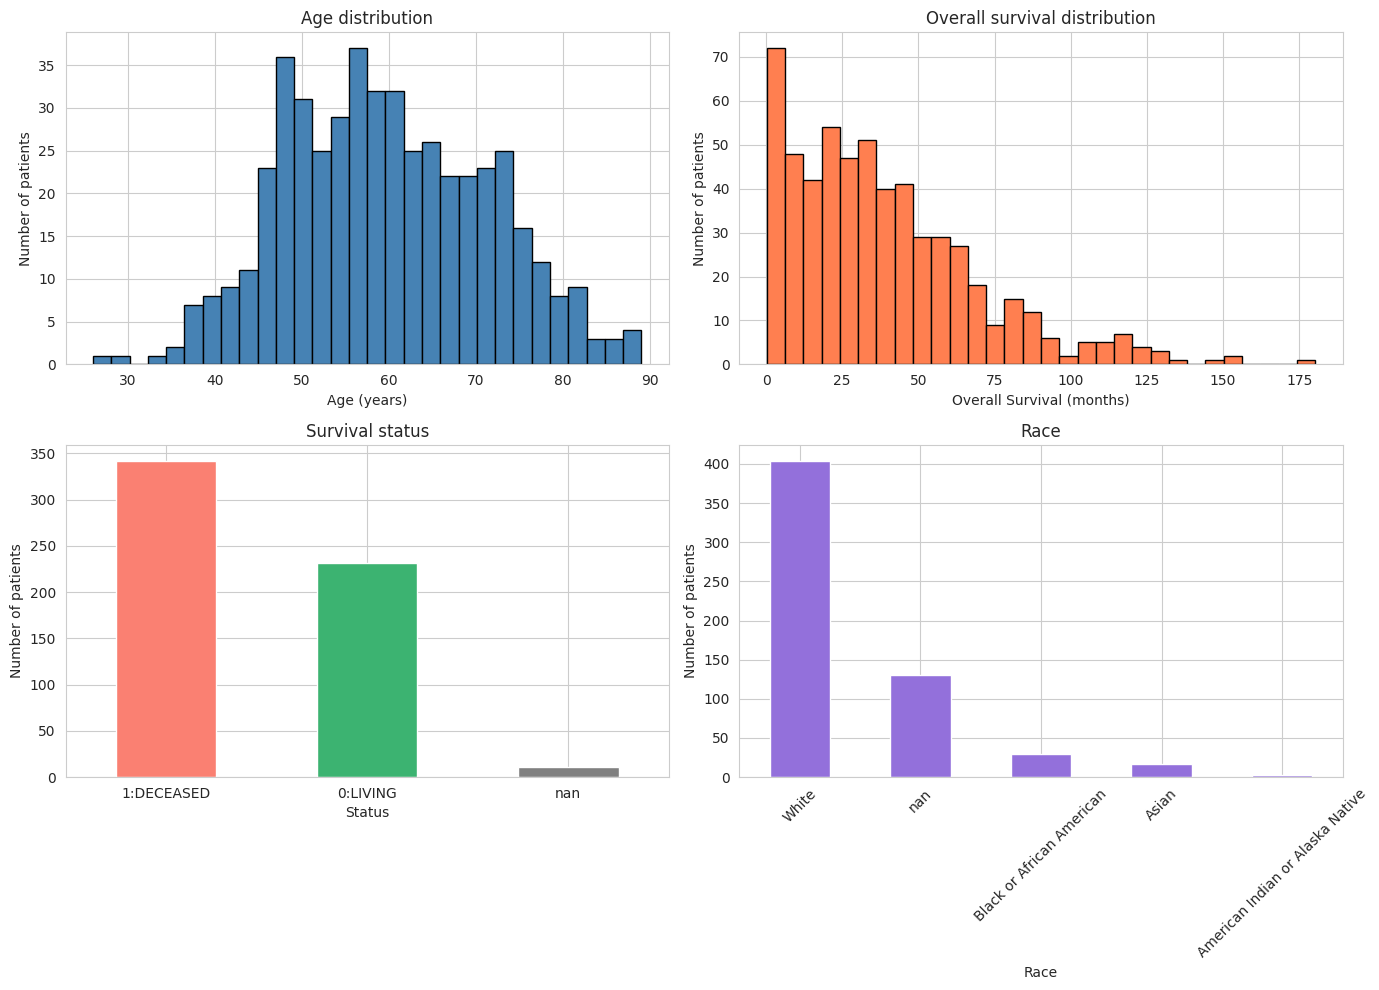

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0, 0].hist(clinical['AGE'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Number of patients')
axes[0, 0].set_title('Age distribution')

# OS_MONTHS distribution
axes[0, 1].hist(clinical['OS_MONTHS'].dropna(), bins=30, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Overall Survival (months)')
axes[0, 1].set_ylabel('Number of patients')
axes[0, 1].set_title('Overall survival distribution')

# OS_STATUS counts
clinical['OS_STATUS'].value_counts(dropna=False).plot(
    kind='bar', ax=axes[1, 0], color=['salmon', 'mediumseagreen', 'gray']
)
axes[1, 0].set_title('Survival status')
axes[1, 0].set_xlabel('Status')
axes[1, 0].set_ylabel('Number of patients')
axes[1, 0].tick_params(axis='x', rotation=0)

# Race distribution
clinical['RACE'].value_counts(dropna=False).plot(
    kind='bar', ax=axes[1, 1], color='mediumpurple'
)
axes[1, 1].set_title('Race')
axes[1, 1].set_xlabel('Race')
axes[1, 1].set_ylabel('Number of patients')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/01_clinical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Loading the gene expression data

The expression file `data_mrna_seq_v2_rsem.txt` contains RNA-seq expression values 
(RSEM-normalized) for thousands of genes across all samples.

In [9]:
# Load the expression file
print("Loading expression data...")
expr = pd.read_csv(
    '../data/raw/data_mrna_seq_v2_rsem.txt',
    sep='\t'
)
print("Done!")

print(f"\nShape: {expr.shape}")
print(f"  - {expr.shape[0]:,} genes")
print(f"  - {expr.shape[1] - 2:,} samples (subtracting Hugo_Symbol and Entrez_Gene_ID)")

# Look at the first few rows and columns
print(f"\nFirst 3 rows x first 6 columns:")
expr.iloc[:3, :6]

Loading expression data...
Done!

Shape: (20531, 302)
  - 20,531 genes
  - 300 samples (subtracting Hugo_Symbol and Entrez_Gene_ID)

First 3 rows x first 6 columns:


,Hugo_Symbol,Entrez_Gene_Id,TCGA-04-1348-01,TCGA-04-1357-01,TCGA-04-1362-01,TCGA-04-1364-01
0,NaN,100130426,NaN,NaN,NaN,NaN
1,NaN,100133144,22.028266,17.671802,21.97672,14.940150
2,UBE2Q2P2,100134869,25.716221,20.473921,29.90998,7.827355


### Quality checks on the expression matrix

Initial inspection revealed potential issues:
1. Some rows have missing gene symbols (Hugo_Symbol = NaN)
2. Some rows have missing expression values

We need to:
- Quantify these issues
- Decide how to handle them
- Check for duplicate gene symbols
- Verify expression value ranges

In [10]:
# Separate the gene info columns from the expression values
gene_info_cols = ['Hugo_Symbol', 'Entrez_Gene_Id']
sample_cols = [col for col in expr.columns if col.startswith('TCGA')]

print(f"Number of gene info columns: {len(gene_info_cols)}")
print(f"Number of sample columns: {len(sample_cols)}")

# Check 1: Missing Hugo_Symbol values
n_missing_hugo = expr['Hugo_Symbol'].isnull().sum()
print(f"\nGenes with missing Hugo_Symbol: {n_missing_hugo}")

# Check 2: Duplicate Hugo_Symbol values
n_duplicate_hugo = expr['Hugo_Symbol'].duplicated().sum()
print(f"Duplicate Hugo_Symbol entries: {n_duplicate_hugo}")

# Check 3: Rows where ALL expression values are missing
all_nan_rows = expr[sample_cols].isnull().all(axis=1).sum()
print(f"Genes with no expression data at all: {all_nan_rows}")

# Check 4: Total cells with NaN in the expression matrix
total_nan_cells = expr[sample_cols].isnull().sum().sum()
total_cells = expr[sample_cols].size
pct_nan = (total_nan_cells / total_cells) * 100
print(f"Total NaN cells: {total_nan_cells:,} / {total_cells:,} ({pct_nan:.2f}%)")

# Check 5: Range of expression values
print(f"\nExpression value statistics:")
all_values = expr[sample_cols].values.flatten()
all_values_clean = all_values[~np.isnan(all_values)]
print(f"Min:    {all_values_clean.min():,.2f}")
print(f"Max:    {all_values_clean.max():,.2f}")
print(f"Mean:   {all_values_clean.mean():,.2f}")
print(f"Median: {np.median(all_values_clean):,.2f}")

Number of gene info columns: 2
Number of sample columns: 300

Genes with missing Hugo_Symbol: 13
Duplicate Hugo_Symbol entries: 19
Genes with no expression data at all: 1455
Total NaN cells: 436,500 / 6,159,300 (7.09%)

Expression value statistics:
Min:    -0.98
Max:    1,442,171.72
Mean:   1,051.58
Median: 256.77


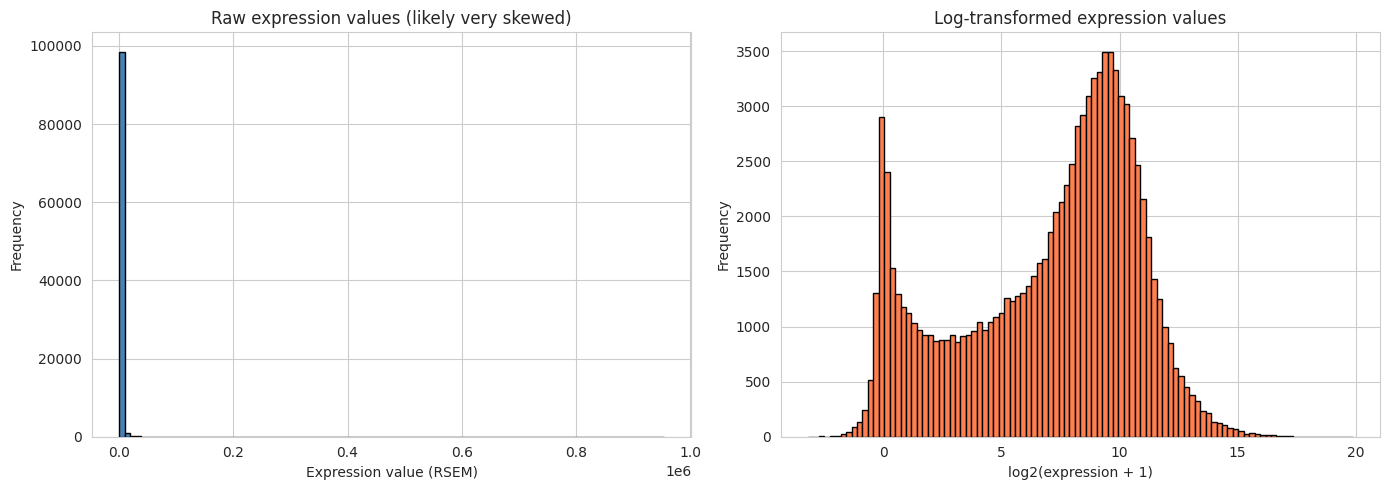

In [11]:
# Plot the distribution of expression values to understand the data shape
# Taking a subset to keep it fast
sample_values = np.random.choice(all_values_clean, size=min(100000, len(all_values_clean)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw values - probably very skewed
axes[0].hist(sample_values, bins=100, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Expression value (RSEM)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Raw expression values (likely very skewed)')

# Log-transformed - should look more bell-shaped
log_values = np.log2(sample_values + 1)  # +1 to handle zeros
axes[1].hist(log_values, bins=100, color='coral', edgecolor='black')
axes[1].set_xlabel('log2(expression + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-transformed expression values')

plt.tight_layout()
plt.savefig('../figures/02_expression_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Cleaning the expression matrix

Based on the quality checks, we will:

1. **Drop genes with missing Hugo_Symbol** (13 genes - no biological identifier)
2. **Drop genes with NO expression data** (1,455 genes - completely empty)
3. **Handle duplicate gene symbols** by keeping the one with highest mean expression (more reliable signal)
4. **Set tiny negative values to 0** (floating-point noise from RSEM)
5. **Set Hugo_Symbol as the index** for cleaner downstream analysis

In [12]:
print(f"Starting shape: {expr.shape}")
print()

# Step 1: Drop rows with missing Hugo_Symbol
expr_clean = expr.dropna(subset=['Hugo_Symbol']).copy()
print(f"After dropping missing Hugo_Symbol: {expr_clean.shape}")

# Step 2: Drop rows where ALL expression values are NaN
expr_clean = expr_clean.dropna(subset=sample_cols, how='all')
print(f"After dropping all-NaN genes: {expr_clean.shape}")

# Step 3: Handle duplicate gene symbols
# For duplicates, keep the row with highest mean expression
expr_clean['_mean_expr'] = expr_clean[sample_cols].mean(axis=1)
expr_clean = expr_clean.sort_values('_mean_expr', ascending=False)
expr_clean = expr_clean.drop_duplicates(subset='Hugo_Symbol', keep='first')
expr_clean = expr_clean.drop(columns=['_mean_expr'])
print(f"After removing duplicates: {expr_clean.shape}")

# Step 4: Set Hugo_Symbol as index, drop Entrez_Gene_Id
expr_clean = expr_clean.set_index('Hugo_Symbol')
expr_clean = expr_clean.drop(columns=['Entrez_Gene_Id'])
print(f"After setting index: {expr_clean.shape}")

# Step 5: Replace any remaining NaN with 0 and clip negatives to 0
# (Negative RSEM values are floating-point noise)
n_negatives = (expr_clean < 0).sum().sum()
print(f"\nNegative values to clip: {n_negatives}")
expr_clean = expr_clean.clip(lower=0)

n_remaining_nan = expr_clean.isnull().sum().sum()
print(f"Remaining NaN values: {n_remaining_nan}")
expr_clean = expr_clean.fillna(0)

print(f"\nFinal shape: {expr_clean.shape}")
print(f"- {expr_clean.shape[0]:,} genes")
print(f"- {expr_clean.shape[1]:,} samples")

# Preview
expr_clean.iloc[:5, :5]

Starting shape: (20531, 302)

After dropping missing Hugo_Symbol: (20518, 302)
After dropping all-NaN genes: (19068, 302)
After removing duplicates: (19062, 302)
After setting index: (19062, 300)

Negative values to clip: 238872
Remaining NaN values: 0

 Final shape: (19062, 300)
- 19,062 genes
- 300 samples


,TCGA-04-1348-01,TCGA-04-1357-01,TCGA-04-1362-01,TCGA-04-1364-01,TCGA-04-1365-01
Hugo_Symbol,,,,,
EEF1A1,52277.622900,152674.031174,141899.920172,110270.100929,76743.884683
GAPDH,128030.337803,83403.811507,74977.195396,33720.358096,110735.083237
ACTB,142652.193771,112811.228287,91455.879172,111564.391289,123804.768217
COL1A1,19648.601950,33601.173156,12492.413177,7588.251280,12034.689460
TPT1,64877.179816,74771.755621,67361.895322,46692.999582,35127.346328


### Matching expression samples to clinical patients

The expression matrix uses sample IDs (TCGA-XX-XXXX-**01**) where -01 is the sample type.
The clinical data uses patient IDs (TCGA-XX-XXXX) without sample suffix.

Need to match these for analysis.

In [13]:
# Extract patient ID from sample ID (drop the last segment, e.g., -01)
sample_to_patient = {
    sample: '-'.join(sample.split('-')[:3])
    for sample in expr_clean.columns
}

# Get the unique patient IDs from the expression data
patients_in_expr = set(sample_to_patient.values())
patients_in_clinical = set(clinical['PATIENT_ID'])

print(f"Patients in expression data: {len(patients_in_expr)}")
print(f"Patients in clinical data: {len(patients_in_clinical)}")
print(f"Patients in BOTH: {len(patients_in_expr & patients_in_clinical)}")
print(f"In expression but not clinical: {len(patients_in_expr - patients_in_clinical)}")
print(f"In clinical but not expression: {len(patients_in_clinical - patients_in_expr)}")

# Check for duplicate samples per patient (some patients have multiple samples)
sample_counts_per_patient = pd.Series(sample_to_patient.values()).value_counts()
n_patients_multi_samples = (sample_counts_per_patient > 1).sum()
print(f"\nPatients with multiple samples: {n_patients_multi_samples}")
if n_patients_multi_samples > 0:
    print("Examples:")
    print(sample_counts_per_patient[sample_counts_per_patient > 1].head())

Patients in expression data: 300
Patients in clinical data: 585
Patients in BOTH: 300
In expression but not clinical: 0
In clinical but not expression: 285

Patients with multiple samples: 0


### Final aligned dataset

Summary of the cleaning process:

| Step | Result |
|------|--------|
| Original genes | 20,531 |
| Original samples in expression file | 300 |
| Genes after cleaning | 19,062 |
| Samples after cleaning | 300 |
| Patients with both clinical + expression data | 300 |

Now we save the cleaned data so we can load it directly in subsequent notebooks without redoing the cleaning.

In [14]:
import os

# To make sure the output directory exists
os.makedirs('../data/processed', exist_ok=True)

# Subset clinical data to only patients we have expression for
patients_with_both = list(patients_in_expr & patients_in_clinical)
clinical_aligned = clinical[clinical['PATIENT_ID'].isin(patients_with_both)].copy()
clinical_aligned = clinical_aligned.reset_index(drop=True)

print(f"Aligned clinical data shape: {clinical_aligned.shape}")
print(f"Cleaned expression data shape: {expr_clean.shape}")

# Save both
expr_clean.to_csv('../data/processed/expression_cleaned.csv')
clinical_aligned.to_csv('../data/processed/clinical_aligned.csv', index=False)

# Also save a sample-to-patient mapping
mapping_df = pd.DataFrame([
    {'sample_id': s, 'patient_id': p} 
    for s, p in sample_to_patient.items()
])
mapping_df.to_csv('../data/processed/sample_patient_mapping.csv', index=False)

print("\nSaved cleaned data to ../data/processed/")
print("  - expression_cleaned.csv")
print("  - clinical_aligned.csv")
print("  - sample_patient_mapping.csv")

Aligned clinical data shape: (300, 38)
Cleaned expression data shape: (19062, 300)

Saved cleaned data to ../data/processed/
  - expression_cleaned.csv
  - clinical_aligned.csv
  - sample_patient_mapping.csv
